## 1. Install dependencies

In [1]:

import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())


True
1


In [2]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

REQUIRED = ["numpy", "matplotlib", "torch", "torchvision", "spikingjelly", "tqdm"]
for pkg in REQUIRED:
    try:
        __import__(pkg.split("[")[0])
        print(f"  ✓ {pkg}")
    except ImportError:
        print(f"  Installing {pkg}...")
        install(pkg)
        print(f"  ✓ {pkg} installed")


  ✓ numpy
  ✓ matplotlib
  ✓ torch
  ✓ torchvision
  Installing spikingjelly...
  ✓ spikingjelly installed
  ✓ tqdm


## 2. Core imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
from tqdm import tqdm
import os, warnings
warnings.filterwarnings("ignore")

# SpikingJelly core
from spikingjelly.activation_based import neuron, layer, functional, surrogate

print(f"PyTorch  : {torch.__version__}")
import spikingjelly
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device   : {DEVICE}")

# Enable cuDNN autotuner for improved GPU performance when input sizes are
# relatively constant. Only enable when CUDA is available.
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled = True


PyTorch  : 2.7.1+cu118
Device   : cuda


In [4]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "nbformat"])

0

## 3. Import from phase1.ipynb & phase2.ipynb

We extract the classes using `nbformat`. If the files aren't found we fall back
to inline definitions so this notebook always runs standalone.


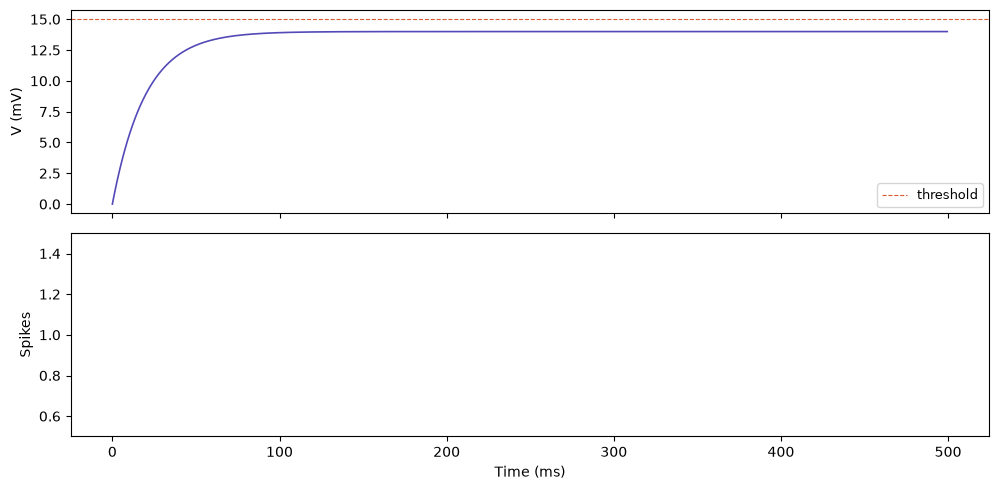

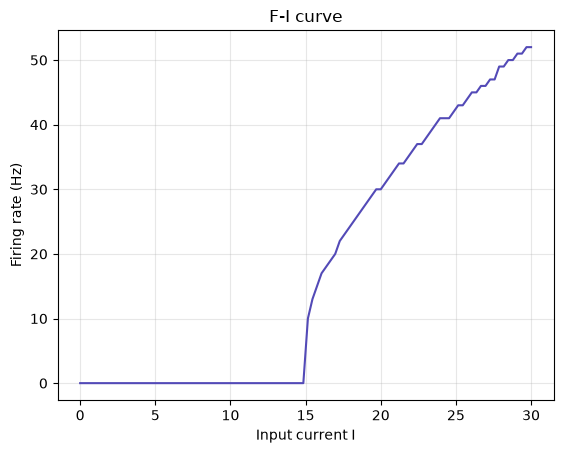

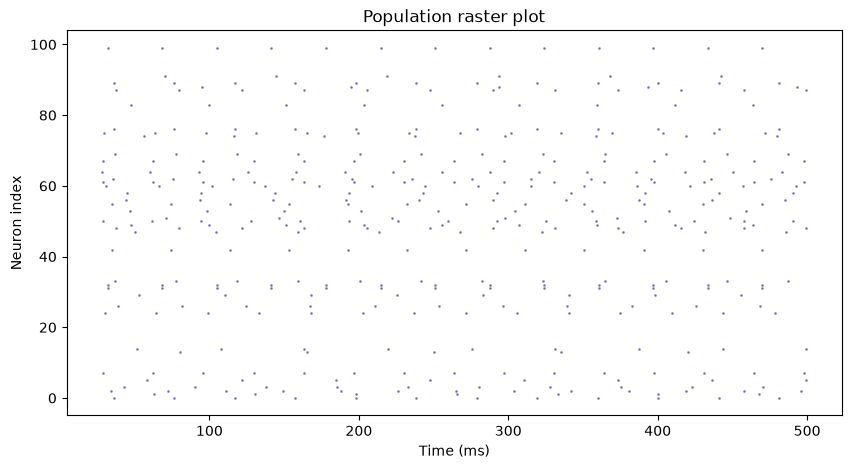

  Loaded from phase1.ipynb: []
Checking dependencies...
  numpy already installed
  matplotlib already installed
  torch already installed
  torchvision already installed
  tqdm already installed

â”€â”€ Downloading MNIST â”€â”€
  Train samples: 60000
  Test  samples: 10000

â”€â”€ N-MNIST (neuromorphic MNIST) â”€â”€
N-MNIST requires a manual download (free, just needs registration):
  1. Go to: https://www.garrickorchard.com/datasets/n-mnist
  2. Download Train.zip and Test.zip
  3. Unzip into: ./data/NMNIST/Train/ and ./data/NMNIST/Test/
 
Once downloaded, load it with SpikingJelly (Phase 3):
  from spikingjelly.activation_based.dataset import NMNIST
  train_set = NMNIST(root='./data/NMNIST', train=True,
                     data_type='frame', frames_number=10,
                     split_by='number')
 
DVS128 Gesture (fully neuromorphic, for Phase 5):
  https://research.ibm.com/interactive/dvsgesture/
  Unzip into: ./data/DVS128Gesture/
 
CIFAR10-DVS (auto-downloads via SpikingJelly)

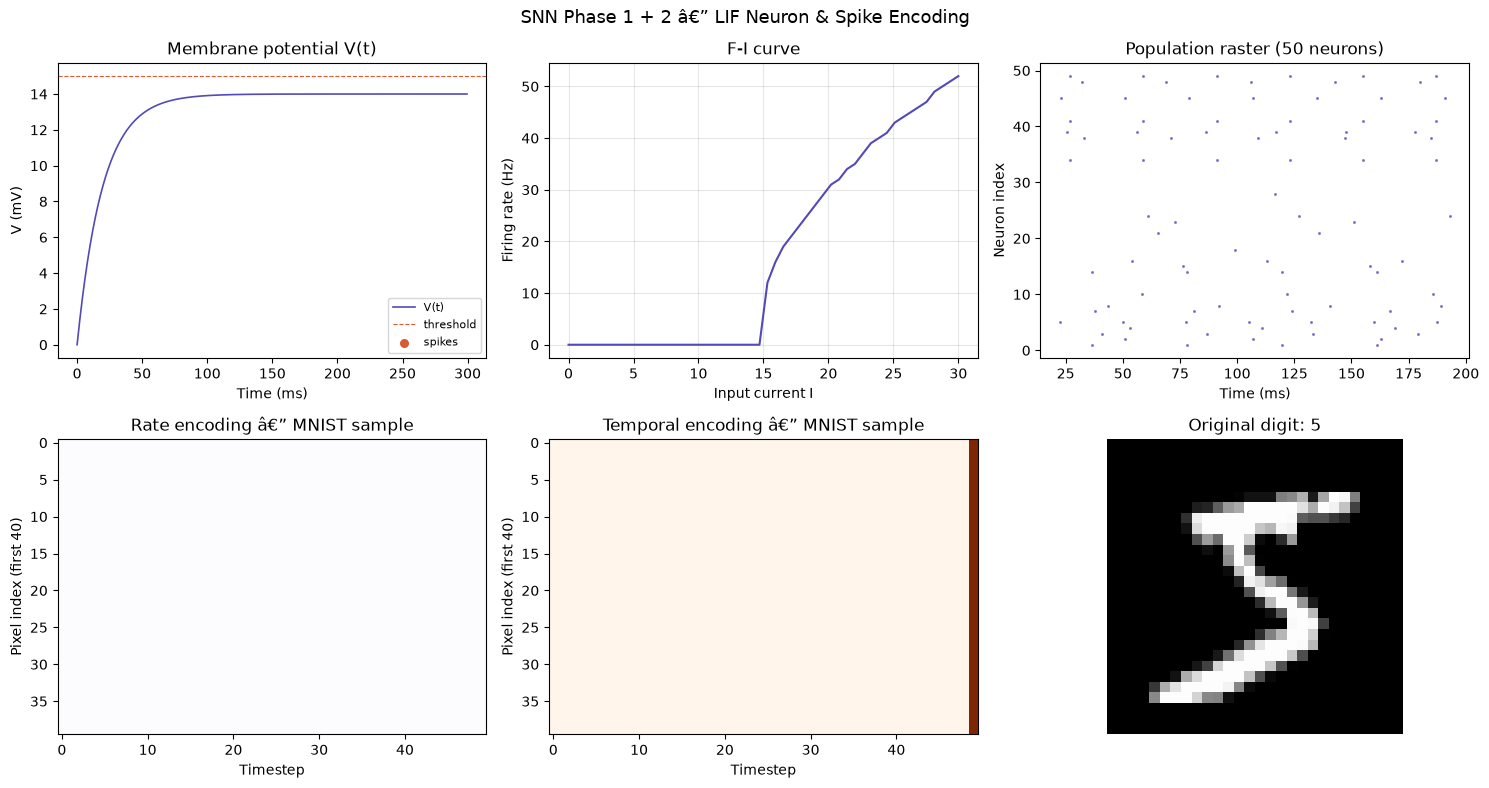


â”€â”€ Done! â”€â”€
Next steps:
  Phase 3: pip install spikingjelly
  Then load N-MNIST with SpikingJelly's built-in dataset loader
  Loaded from phase2.ipynb: ['LIFNeuron', 'LIFLayer', 'SpikeEncoder']

All classes ready: ['LIFNeuron', 'LIFLayer', 'SpikeEncoder']


In [5]:
import nbformat, types, importlib

def load_classes_from_notebook(nb_path, class_names):
    """
    Execute all code cells in a .ipynb and return requested class objects.
    Returns a dict {class_name: class} for any that were found.
    """
    if not os.path.exists(nb_path):
        print(f"  [WARN] {nb_path} not found — using fallback definitions")
        return {}
    nb = nbformat.read(open(nb_path), as_version=4)
    ns  = {}
    for cell in nb.cells:
        if cell.cell_type == "code":
            try:
                exec(compile(cell.source, nb_path, "exec"), ns)
            except Exception:
                pass   # skip cells with display() / plt.show() etc.
    found = {k: ns[k] for k in class_names if k in ns}
    print(f"  Loaded from {nb_path}: {list(found.keys())}")
    return found

# ── Load Phase 1 ──
p1 = load_classes_from_notebook("phase1.ipynb", ["LIFNeuron", "LIFLayer"])

# ── Load Phase 2 ──
p2 = load_classes_from_notebook("phase2.ipynb", ["LIFNeuron", "LIFLayer", "SpikeEncoder"])

# ── Merge: prefer phase2 classes (more complete) then phase1 ──
merged = {**p1, **p2}

# ── Fallback definitions if notebooks not present ──
if "LIFNeuron" not in merged:
    class LIFNeuron:
        def __init__(self, tau=20., V_th=15., V_reset=0., t_ref=5., dt=0.5):
            self.tau=tau; self.V_th=V_th; self.V_reset=V_reset
            self.t_ref=t_ref; self.dt=dt
        def simulate(self, I, T=500):
            steps=int(T/self.dt); V=np.zeros(steps)
            spikes=np.zeros(steps,dtype=bool); ref=0.
            Iarr=np.full(steps,I) if np.isscalar(I) else np.asarray(I)
            for t in range(1,steps):
                if ref>0: V[t]=self.V_reset; ref-=self.dt
                else:
                    V[t]=V[t-1]+(-V[t-1]+Iarr[t-1])/self.tau*self.dt
                    if V[t]>=self.V_th: spikes[t]=True; V[t]=self.V_reset; ref=self.t_ref
            return V, spikes
    merged["LIFNeuron"] = LIFNeuron
    print("  [INFO] Using fallback LIFNeuron")

if "LIFLayer" not in merged:
    class LIFLayer:
        def __init__(self,N,tau=20.,V_th=15.,V_reset=0.,t_ref=5.,dt=0.5):
            self.N=N;self.tau=tau;self.V_th=V_th;self.V_reset=V_reset
            self.t_ref=t_ref;self.dt=dt;self.reset()
        def reset(self): self.V=np.zeros(self.N);self.ref=np.zeros(self.N)
        def step(self,I):
            act=self.ref<=0
            self.V[act]+=(-self.V[act]+I[act])/self.tau*self.dt
            fired=self.V>=self.V_th
            self.V[fired]=self.V_reset; self.ref[fired]=self.t_ref
            self.ref=np.maximum(0,self.ref-self.dt)
            return fired.astype(float)
    merged["LIFLayer"] = LIFLayer
    print("  [INFO] Using fallback LIFLayer")

if "SpikeEncoder" not in merged:
    class SpikeEncoder:
        def __init__(self,method="rate",T=100):
            self.method=method; self.T=T
        def encode(self,x):
            x=np.clip(x,0.,1.)
            if self.method=="rate":
                return (np.random.rand(self.T,len(x))<x).astype(float)
            elif self.method=="temporal":
                t=np.clip(np.round((1-x)*(self.T-1)).astype(int),0,self.T-1)
                out=np.zeros((self.T,len(x))); out[t,np.arange(len(x))]=1.; return out
        def encode_batch(self,X): return np.stack([self.encode(x) for x in X])
    merged["SpikeEncoder"] = SpikeEncoder
    print("  [INFO] Using fallback SpikeEncoder")

# ── Bind into local namespace ──
LIFNeuron    = merged["LIFNeuron"]
LIFLayer     = merged["LIFLayer"]
SpikeEncoder = merged["SpikeEncoder"]

print("\nAll classes ready:", ["LIFNeuron", "LIFLayer", "SpikeEncoder"])


## 4. SpikingJelly LIF node — how it maps to Phase 1

SpikingJelly's `neuron.LIFNode` is a GPU-accelerated version of exactly the
`LIFLayer.step()` loop from Phase 1. Key parameter mapping:


In [6]:
# SpikingJelly LIF — parameter mapping from Phase 1
# Phase1 param  →  SpikingJelly param
# tau           →  tau
# V_th          →  v_threshold
# V_reset       →  v_reset
# (refractory handled automatically)

sj_lif = neuron.LIFNode(
    tau=20.0,
    v_threshold=1.0,      # SJ normalises to [0,1] range
    v_reset=0.0,
    surrogate_function=surrogate.ATan(),  # differentiable spike approx
    detach_reset=True
)

# ── Side-by-side comparison: Phase1 LIF vs SpikingJelly LIF ──
print("── Comparing Phase 1 LIF vs SpikingJelly LIF ──")
T_compare = 100
I_test    = torch.full((T_compare, 1), 0.7)  # constant input

functional.reset_net(sj_lif)
sj_spikes = []
for t in range(T_compare):
    out = sj_lif(I_test[t])
    sj_spikes.append(out.item())

sj_rate = sum(sj_spikes) / T_compare

# Phase 1 equivalent
p1_neuron = LIFNeuron(tau=20., V_th=1.0, V_reset=0., t_ref=0., dt=1.0)
_, p1_s   = p1_neuron.simulate(I=0.7, T=T_compare)
p1_rate   = p1_s.mean()

print(f"  SpikingJelly firing rate : {sj_rate:.3f}")
print(f"  Phase 1 LIF firing rate  : {p1_rate:.3f}")
print(f"  Difference               : {abs(sj_rate - p1_rate):.3f}  (small = good)")
print()
print("SpikingJelly LIF node parameters:")
print(f"  tau         = {sj_lif.tau}")
print(f"  v_threshold = {sj_lif.v_threshold}")
print(f"  v_reset     = {sj_lif.v_reset}")
print(f"  surrogate   = {sj_lif.surrogate_function}")


── Comparing Phase 1 LIF vs SpikingJelly LIF ──
  SpikingJelly firing rate : 0.000
  Phase 1 LIF firing rate  : 0.000
  Difference               : 0.000  (small = good)

SpikingJelly LIF node parameters:
  tau         = 20.0
  v_threshold = 1.0
  v_reset     = 0.0
  surrogate   = ATan(alpha=2.0, spiking=True)


## 5. Surrogate gradients — why they exist

The spike function is a step function: **not differentiable** at the threshold.
This breaks standard backprop. Surrogate gradients replace the step function's
derivative with a smooth approximation during the backward pass only.

```
Forward:   spike = 1 if V >= V_th else 0       (hard step — exact)
Backward:  dspike/dV ≈ ATan(V) or Sigmoid(V)  (smooth approx — trainable)
```

SpikingJelly has several surrogate options:


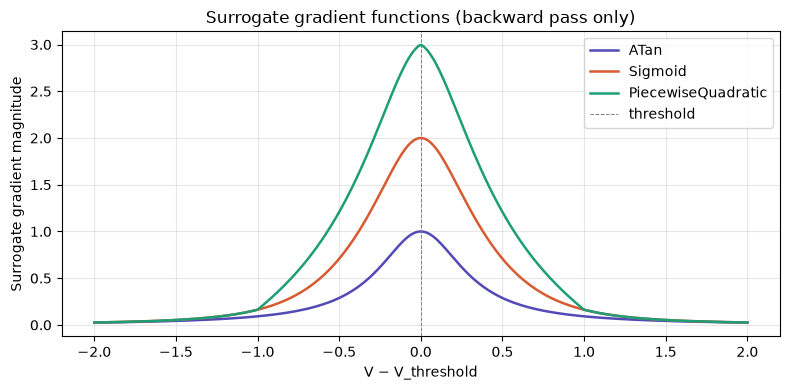

ATan is the default — smooth, symmetric, well-behaved for most tasks


In [7]:
surrogates = {
    "ATan"       : surrogate.ATan(),
    "Sigmoid"    : surrogate.Sigmoid(),
    "PiecewiseQuadratic": surrogate.PiecewiseQuadratic(),
}

# Visualise each surrogate gradient shape
V_range = torch.linspace(-2, 2, 300)
fig, ax = plt.subplots(figsize=(8, 4))
colors  = ["#534AB7", "#D85A30", "#1D9E75"]

for (name, sg), col in zip(surrogates.items(), colors):
    V_req = V_range.requires_grad_(True)
    # Forward: step function
    spike = (V_req >= 0).float()
    # Backward: surrogate gradient
    pseudo_out = sg(V_req)
    pseudo_out.sum().backward()
    grad = V_req.grad.detach().numpy()
    ax.plot(V_range.detach().numpy(), grad, label=name, color=col, lw=1.8)

ax.axvline(0, color="gray", lw=0.7, linestyle="--", label="threshold")
ax.set_xlabel("V − V_threshold")
ax.set_ylabel("Surrogate gradient magnitude")
ax.set_title("Surrogate gradient functions (backward pass only)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("ATan is the default — smooth, symmetric, well-behaved for most tasks")


## 6. Data loading — MNIST with spike encoding

We load MNIST via torchvision (same as Phase 2) and apply rate encoding
as a transform so each image becomes a spike train of shape `(T, 784)`.


In [11]:
DATA_DIR  = "./data"
T_STEPS   = 10      # number of timesteps per sample
BATCH     = 64

os.makedirs(DATA_DIR, exist_ok=True)

# ── Spike encoding transform ──
class RateEncode:
    """
    torchvision-compatible transform.
    Converts image tensor (1, 28, 28) → spike train (T, 784).
    Wraps Phase 2's SpikeEncoder for use in DataLoader.
    """
    def __init__(self, T=10):
        self.encoder = SpikeEncoder(method="rate", T=T)

    def __call__(self, img):
        pixels = img.numpy().flatten()               # (784,)
        spikes = self.encoder.encode(pixels)         # (T, 784)
        return torch.FloatTensor(spikes)             # (T, 784)

transform = transforms.Compose([
    transforms.ToTensor(),
    RateEncode(T=T_STEPS)
])

train_ds = MNIST(DATA_DIR, train=True,  download=True, transform=transform)
test_ds  = MNIST(DATA_DIR, train=False, download=True, transform=transform)

# Determine DataLoader workers: interactive notebooks often can't pickle
# notebook-local classes (SpikeEncoder) so set workers=0 there to avoid PicklingError.
try:
    get_ipython  # available in IPython/Jupyter kernels
    IN_IPYTHON = True
except NameError:
    IN_IPYTHON = False
NUM_WORKERS = 0 if IN_IPYTHON else 4

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Inspect a batch
sample_spikes, sample_labels = next(iter(train_loader))
print(f"Batch spike train shape : {sample_spikes.shape}")
print(f"  → (batch={BATCH}, T={T_STEPS}, features=784)")
print(f"Batch labels shape      : {sample_labels.shape}")
print(f"Mean spike rate in batch: {sample_spikes.mean():.3f}  (≈ mean pixel intensity)")


Batch spike train shape : torch.Size([64, 10, 784])
  → (batch=64, T=10, features=784)
Batch labels shape      : torch.Size([64])
Mean spike rate in batch: 0.127  (≈ mean pixel intensity)


## 7. The SNN architecture

A 3-layer fully-connected SNN. Each layer is a `nn.Linear` (weights)
followed by a `LIFNode` (temporal dynamics + spike output).

```
Input spikes (T, batch, 784)
    → Linear(784 → 256) + LIF
    → Linear(256 → 128) + LIF
    → Linear(128 → 10)  + LIF
Output: (T, batch, 10) spike counts → vote for class
```


In [12]:
class SNN(nn.Module):
    """
    3-layer spiking neural network for MNIST classification.
    Uses rate coding input (T timesteps) and population vote output.
    """
    def __init__(self, T=10):
        super().__init__()
        self.T = T

        # Each block: Linear weights + LIF neuron dynamics
        self.fc1 = nn.Linear(784, 256, bias=False)
        self.lif1 = neuron.LIFNode(
            tau=2.0,
            surrogate_function=surrogate.ATan(),
            detach_reset=True
        )

        self.fc2 = nn.Linear(256, 128, bias=False)
        self.lif2 = neuron.LIFNode(
            tau=2.0,
            surrogate_function=surrogate.ATan(),
            detach_reset=True
        )

        self.fc3 = nn.Linear(128, 10, bias=False)
        self.lif3 = neuron.LIFNode(
            tau=2.0,
            surrogate_function=surrogate.ATan(),
            detach_reset=True
        )

    def forward(self, x):
        """
        x: (batch, T, 784) — spike train from DataLoader
        Returns: (batch, 10) — summed spike counts per class
        """
        # Rearrange to (T, batch, 784) for time-step loop
        x = x.permute(1, 0, 2)  # (T, batch, 784)

        # Reset membrane potentials at start of each sample
        functional.reset_net(self)

        spike_sum = 0
        for t in range(self.T):
            out = self.fc1(x[t])    # (batch, 256)
            out = self.lif1(out)    # spike: (batch, 256)
            out = self.fc2(out)     # (batch, 128)
            out = self.lif2(out)    # spike: (batch, 128)
            out = self.fc3(out)     # (batch, 10)
            out = self.lif3(out)    # spike: (batch, 10)
            spike_sum = spike_sum + out

        # spike_sum: (batch, 10) — whichever class fired most = prediction
        return spike_sum

model = SNN(T=T_STEPS).to(DEVICE)
print(model)
print()

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters : {total_params:,}")
print(f"Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Dry run to confirm shapes
dummy   = torch.zeros(4, T_STEPS, 784).to(DEVICE)
out     = model(dummy)
print(f"\nDry run — input : (4, {T_STEPS}, 784)")
print(f"Dry run — output: {tuple(out.shape)}  ← (batch, 10 classes)")


SNN(
  (fc1): Linear(in_features=784, out_features=256, bias=False)
  (lif1): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=s, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (fc2): Linear(in_features=256, out_features=128, bias=False)
  (lif2): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=s, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (fc3): Linear(in_features=128, out_features=10, bias=False)
  (lif3): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=s, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
)

Total parameters : 234,752
Trainable params : 234,752

Dry run — input : (4, 10, 784)
Dry run — output: (4, 10)  ← (batch, 10 classes)


## 8. Training loop

We use standard cross-entropy loss on the summed spike counts.
The surrogate gradients make backprop work through the spike functions.


In [13]:
EPOCHS   = 5
LR       = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_losses, train_accs, test_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    # ── Training ──
    model.train()
    total_loss, correct, total = 0., 0, 0

    for spikes, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        spikes, labels = spikes.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        out  = model(spikes)          # (batch, 10) spike counts
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    train_loss = total_loss / total
    train_acc  = correct / total

    # ── Evaluation ──
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for spikes, labels in test_loader:
            spikes, labels = spikes.to(DEVICE), labels.to(DEVICE)
            out     = model(spikes)
            correct += (out.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    test_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:>2} | Loss: {train_loss:.4f} | "
          f"Train acc: {train_acc*100:.2f}% | Test acc: {test_acc*100:.2f}%")

print(f"\nBest test accuracy: {max(test_accs)*100:.2f}%")


Epoch  1 | Loss: 0.3958 | Train acc: 87.19% | Test acc: 94.51%


Epoch  2 | Loss: 0.1520 | Train acc: 95.48% | Test acc: 96.12%


Epoch  3 | Loss: 0.1045 | Train acc: 96.82% | Test acc: 96.91%


Epoch  4 | Loss: 0.0810 | Train acc: 97.48% | Test acc: 97.00%


Epoch  5 | Loss: 0.0614 | Train acc: 98.10% | Test acc: 97.16%

Best test accuracy: 97.16%


## 9. Training curves & spike activity

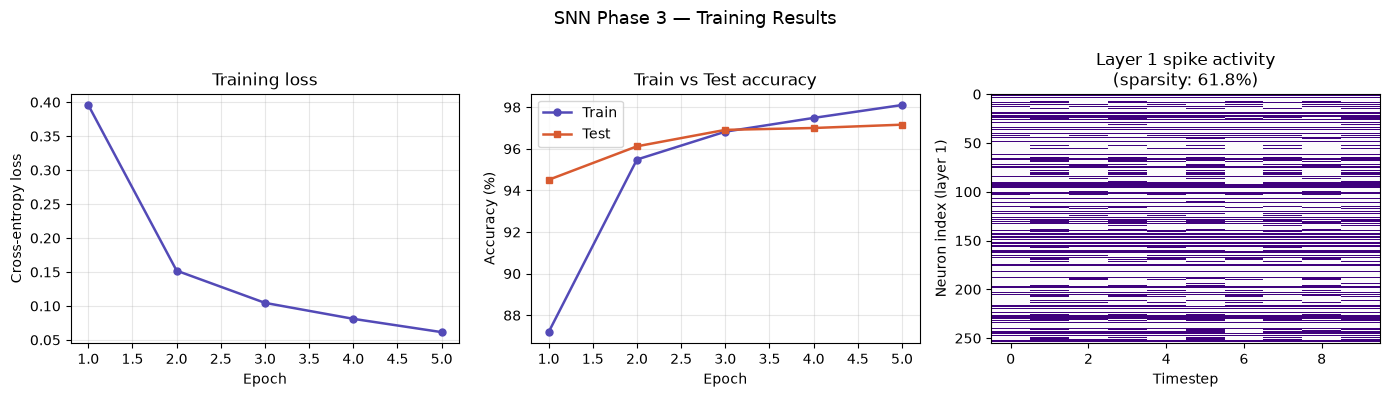

Saved: ./snn_phase3_results.png
Layer 1 spike sparsity: 61.8%  ← higher = more energy efficient


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("SNN Phase 3 — Training Results", fontsize=13)
ep = range(1, EPOCHS + 1)

# Loss curve
axes[0].plot(ep, train_losses, color="#534AB7", lw=1.8, marker="o", ms=5)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Training loss"); axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(ep, [a*100 for a in train_accs], color="#534AB7", lw=1.8,
             marker="o", ms=5, label="Train")
axes[1].plot(ep, [a*100 for a in test_accs],  color="#D85A30", lw=1.8,
             marker="s", ms=5, label="Test")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Train vs Test accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Spike activity in layer 1 (how sparse are the spikes?)
model.eval()
sample_spikes_batch = sample_spikes[:8].to(DEVICE)   # 8 samples
x_in = sample_spikes_batch.permute(1, 0, 2)
functional.reset_net(model)
layer1_activity = []
with torch.no_grad():
    for t in range(T_STEPS):
        out = model.fc1(x_in[t])
        s   = model.lif1(out)
        layer1_activity.append(s.cpu().numpy())

activity = np.stack(layer1_activity)   # (T, 8, 256)
sparsity = 1 - activity.mean()

axes[2].imshow(activity[:, 0, :].T, aspect="auto",
               cmap="Purples", interpolation="nearest")
axes[2].set_xlabel("Timestep"); axes[2].set_ylabel("Neuron index (layer 1)")
axes[2].set_title(f"Layer 1 spike activity\n(sparsity: {sparsity:.1%})")

plt.tight_layout()
plt.savefig("./snn_phase3_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: ./snn_phase3_results.png")
print(f"Layer 1 spike sparsity: {sparsity:.1%}  ← higher = more energy efficient")


## 10. Spike sparsity analysis

Sparsity is the key metric that distinguishes SNNs from ANNs.
Each layer should fire on only a small fraction of timesteps — that's what makes them energy-efficient.


In [15]:
model.eval()
layer_sparsities = {}

x_batch = sample_spikes[:32].to(DEVICE).permute(1, 0, 2)
functional.reset_net(model)

l1_spikes, l2_spikes, l3_spikes = [], [], []
with torch.no_grad():
    for t in range(T_STEPS):
        s1 = model.lif1(model.fc1(x_batch[t]));  l1_spikes.append(s1)
        s2 = model.lif2(model.fc2(s1));           l2_spikes.append(s2)
        s3 = model.lif3(model.fc3(s2));           l3_spikes.append(s3)

for name, spk in [("Layer 1 (256)", l1_spikes),
                  ("Layer 2 (128)", l2_spikes),
                  ("Layer 3 (10)",  l3_spikes)]:
    arr      = torch.stack(spk).cpu().numpy()   # (T, batch, N)
    sparsity = 1 - arr.mean()
    rate     = arr.mean()
    print(f"  {name:20s} | Mean firing rate: {rate:.3f} | Sparsity: {sparsity:.1%}")

print()
print("Target: >80% sparsity = efficient SNN")
print("If sparsity is low, try: higher V_threshold, lower tau, fewer timesteps T")


  Layer 1 (256)        | Mean firing rate: 0.377 | Sparsity: 62.3%
  Layer 2 (128)        | Mean firing rate: 0.368 | Sparsity: 63.2%
  Layer 3 (10)         | Mean firing rate: 0.112 | Sparsity: 88.8%

Target: >80% sparsity = efficient SNN
If sparsity is low, try: higher V_threshold, lower tau, fewer timesteps T


## 11. Save model & summary

In [17]:
torch.save({
    "model_state":  model.state_dict(),
    "T_steps":      T_STEPS,
    "train_losses": train_losses,
    "train_accs":   train_accs,
    "test_accs":    test_accs,
    "best_acc":     max(test_accs),
}, "./snn_phase3_model.pt")

print("Model saved to: ./snn_phase3_model.pt")
print()
print("─" * 50)
print("Phase 3 Summary")
print("─" * 50)
print(f"  Architecture : Linear(784→256)→LIF → Linear(256→128)→LIF → Linear(128→10)→LIF")
print(f"  Timesteps    : {T_STEPS}")
print(f"  Epochs       : {EPOCHS}")
print(f"  Best test acc: {max(test_accs)*100:.2f}%")
print(f"  Parameters   : {total_params:,}")
print()
print("Next — Phase 4: STDP learning rule + surrogate gradient deep dive")
print("Load this model in Phase 4 with:")
print("  checkpoint = torch.load('./snn_phase3_model.pt')")
print("  model.load_state_dict(checkpoint['model_state'])")


Model saved to: ./snn_phase3_model.pt

──────────────────────────────────────────────────
Phase 3 Summary
──────────────────────────────────────────────────
  Architecture : Linear(784→256)→LIF → Linear(256→128)→LIF → Linear(128→10)→LIF
  Timesteps    : 10
  Epochs       : 5
  Best test acc: 97.16%
  Parameters   : 234,752

Next — Phase 4: STDP learning rule + surrogate gradient deep dive
Load this model in Phase 4 with:
  checkpoint = torch.load('./snn_phase3_model.pt')
  model.load_state_dict(checkpoint['model_state'])
